# MC pipeline (stepwise, notebook-first)

**Finish point A (light):** compute MC + sanity checks (no allegiance, no saving big arrays).

**Finish point B (heavy):** compute allegiance/modularity + trimer indices, then *optionally* save one frozen artifact.

Run cells top-to-bottom. Stop after Finish point A unless you explicitly set `RUN_HEAVY = True`.


In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import numpy as np


In [2]:
from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_metaconnectivity import (
    compute_metaconnectivity,
    fun_allegiance_communities,
    get_fc_mc_indices,
    get_mc_region_identities,
    intramodule_indices_mask,
    build_trimer_mask,
    compute_trimers_identity,
)
from shared_code.fun_paths import get_paths


[info] Using PATHS_ROOT=/media/samy/Elements2/Proyectos/LauraHarsan


In [12]:
# ---------------- Dataset ----------------
DATASET = 'ines_abdallah'
TIMECOURSE_FOLDER = 'Timecourses_updated_03052024'
COGNITIVE_FILE = 'ROIs.xlsx'
ANAT_LABELS_FILE = '41_Allen.txt'

BUNDLE_NPZ = 'ts_and_meta_2m4m.npz'
BUNDLE_GROUPING = 'grouping_data_oip.pkl'

# ---------------- MC params ----------------
WINDOW_SIZE = 7
LAG = 1
N_JOBS = -1

# ---------------- Allegiance / modularity ----------------
N_RUNS_ALLEGIANCE = 1000
GAMMA_PT = 100

# ---------------- Reference group selection ----------------
REF_COL = 2
REF_ROW = 0

# ---------------- Workflow gate ----------------
RUN_HEAVY = True  # <-- set True only when Finish point A looks good

RUN_TAG = f"w={WINDOW_SIZE}_lag={LAG}_runs={N_RUNS_ALLEGIANCE}_gamma={GAMMA_PT}_ref={REF_COL}-{REF_ROW}"
print('RUN_TAG:', RUN_TAG)


RUN_TAG: w=7_lag=1_runs=1000_gamma=100_ref=2-0


## Load data bundle
This loads your preprocessed time series + grouping masks.


In [13]:
paths = get_paths(
    dataset_name=DATASET,
    timecourse_folder=TIMECOURSE_FOLDER,
    cognitive_data_file=COGNITIVE_FILE,
    anat_labels_file=ANAT_LABELS_FILE,
)

bundle = load_timeseries_bundle(
    paths['preprocessed'] / BUNDLE_NPZ,
    paths['preprocessed'] / BUNDLE_GROUPING,
)

ts = bundle.ts
n_animals = bundle.n_animals
regions = bundle.n_regions
mask_groups = bundle.mask_groups
label_variables = bundle.label_variables

if mask_groups is None or label_variables is None:
    raise ValueError('Grouping data missing: expected mask_groups and label_variables in bundle.')

print('ts shape:', np.shape(ts))
print('n_animals:', n_animals, 'regions:', regions)
print('n grouping columns:', len(mask_groups))


ts shape: (126, 450, 41)
n_animals: 126 regions: 41
n grouping columns: 4


## Reference group
We only *select* the reference here (no heavy computations yet).


In [14]:
label_ref = label_variables[REF_COL][REF_ROW]
ind_ref = mask_groups[REF_COL][REF_ROW]

print('Reference label:', label_ref)
print('Reference mask type:', type(ind_ref))


Reference label: wt 2m
Reference mask type: <class 'numpy.ndarray'>


## Finish point A — Compute metaconnectivity (MC)
This computes per-animal MC in **edge space**: shape `(animals, E, E)` with `E = regions*(regions-1)/2`.

No big data is saved by default (`save_path=None`).


In [15]:
t0 = time.time()
mc = compute_metaconnectivity(
    ts,
    window_size=WINDOW_SIZE,
    lag=LAG,
    n_jobs=N_JOBS,
    save_path=None,  # no internal saving
)
t1 = time.time()

mc = np.asarray(mc)
print('MC shape:', mc.shape, f'(computed in {t1 - t0:.2f}s)')


[info] Using PATHS_ROOT=/media/samy/Elements2/Proyectos/LauraHarsan
[info] Using PATHS_ROOT=/media/samy/Elements2/Proyectos/LauraHarsan
[info] Using PATHS_ROOT=/media/samy/Elements2/Proyectos/LauraHarsan
[info] Using PATHS_ROOT=/media/samy/Elements2/Proyectos/LauraHarsan
[info] Using PATHS_ROOT=/media/samy/Elements2/Proyectos/LauraHarsan
[info] Using PATHS_ROOT=/media/samy/Elements2/Proyectos/LauraHarsan
[info] Using PATHS_ROOT=/media/samy/Elements2/Proyectos/LauraHarsan
[info] Using PATHS_ROOT=/media/samy/Elements2/Proyectos/LauraHarsan
here
MC shape: (126, 820, 820) (computed in 2.80s)


### MC sanity checks (cheap, required)
If these look wrong, **do not** proceed to allegiance.


In [16]:
E_expected = regions * (regions - 1) // 2
print('E (FC edges) expected:', E_expected)

if mc.ndim != 3 or mc.shape[0] != n_animals or mc.shape[1] != mc.shape[2] or mc.shape[1] != E_expected:
    raise ValueError(f'Unexpected MC shape: {mc.shape} (expected (n_animals,{E_expected},{E_expected}))')

finite = np.isfinite(mc)
print('finite fraction:', float(finite.mean()))

# Diagonal should be ~1 for correlation-like MC (before you later nan it)
diag = np.array([np.diag(mc[a]) for a in range(mc.shape[0])])
print('diag mean ± std:', float(np.nanmean(diag)), float(np.nanstd(diag)))

# Sample off-diagonal distribution (one animal, random subset)
rng = np.random.default_rng(0)
a = int(rng.integers(0, mc.shape[0]))
idx = rng.choice(E_expected, size=300, replace=False)
sub = mc[a][np.ix_(idx, idx)]
off = sub[~np.eye(sub.shape[0], dtype=bool)]
print('off-diag mean ± std:', float(np.nanmean(off)), float(np.nanstd(off)))
print('off-diag min/max:', float(np.nanmin(off)), float(np.nanmax(off)))


E (FC edges) expected: 820
finite fraction: 1.0
diag mean ± std: 1.0 3.025709512904481e-16
off-diag mean ± std: 0.03248509978351723 0.11131851469706787
off-diag min/max: -0.4896479806597422 0.6856982530351878


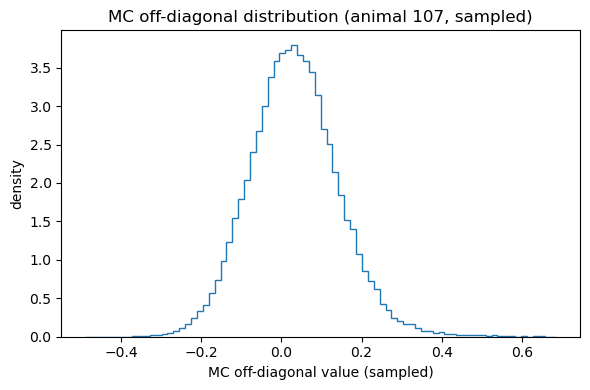

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(off[np.isfinite(off)], bins=80, density=True, histtype='step')
plt.xlabel('MC off-diagonal value (sampled)')
plt.ylabel('density')
plt.title(f'MC off-diagonal distribution (animal {a}, sampled)')
plt.tight_layout()
plt.show()


### STOP HERE unless you explicitly want the heavy steps
Set `RUN_HEAVY = True` above to continue.


In [18]:
if not RUN_HEAVY:
    raise SystemExit('Stopped after Finish point A (MC computed + validated). Set RUN_HEAVY=True to continue.')


## Finish point B — Allegiance, modularity, trimer indices
This is heavy and should only run after MC looks sane.


In [19]:
mc_mod_dir = paths['mc_mod']
trimers_dir = paths.get('trimers', paths['results'] / 'trimers')
frozen_dir = paths['results'] / 'mc_frozen'
for d in (mc_mod_dir, trimers_dir, frozen_dir):
    d.mkdir(parents=True, exist_ok=True)

print('[OK] Output dirs:')
print('  mc_mod   →', mc_mod_dir)
print('  trimers  →', trimers_dir)
print('  mc_frozen→', frozen_dir)


[OK] Output dirs:
  mc_mod   → /media/samy/Elements2/Proyectos/LauraHarsan/results/ines_abdallah/mc_mod
  trimers  → /media/samy/Elements2/Proyectos/LauraHarsan/results/ines_abdallah/trimers
  mc_frozen→ /media/samy/Elements2/Proyectos/LauraHarsan/results/ines_abdallah/mc_frozen


In [21]:
from pathlib import Path
import joblib
import numpy as np

# Where your old cache is
alleg_dir = Path("reports/metaconnectivity") / paths["results"].name / "allegiance"

# Most likely file based on your log
joblib_path = alleg_dir / f"allegiance_{str(label_ref).replace(' ','_')}.joblib"

print("Looking for:", joblib_path)

allegiance_loaded = False
if joblib_path.exists():
    obj = joblib.load(joblib_path)

    # Try to interpret common formats
    if isinstance(obj, dict):
        # expected keys could vary — print to see
        print("Loaded dict keys:", list(obj.keys()))
        # common possibilities:
        mc_ref_allegiance_communities = obj.get("communities", obj.get("mc_ref_allegiance_communities"))
        allegiance_sort = obj.get("sort", obj.get("allegiance_sort", obj.get("mc_ref_allegiance_sort")))
        contingency_matrix = obj.get("contingency_matrix", None)
    else:
        # sometimes joblib stores a tuple
        try:
            mc_ref_allegiance_communities, allegiance_sort, contingency_matrix = obj
        except Exception:
            raise ValueError(f"Don't know how to unpack joblib object type={type(obj)}")

    # Basic sanity
    if mc_ref_allegiance_communities is None or allegiance_sort is None:
        raise ValueError("Loaded allegiance cache but couldn't find communities/sort inside it.")

    mc_ref_allegiance_communities = np.asarray(mc_ref_allegiance_communities)
    allegiance_sort = np.asarray(allegiance_sort)

    print("[OK] Loaded cached allegiance")
    print("  communities shape:", mc_ref_allegiance_communities.shape)
    print("  allegiance_sort length:", len(allegiance_sort))

    allegiance_loaded = True

if not allegiance_loaded:
    print("[MISS] No usable cache found → will compute allegiance now")


Looking for: reports/metaconnectivity/ines_abdallah/allegiance/allegiance_wt_2m.joblib
[OK] Loaded cached allegiance
  communities shape: (820,)
  allegiance_sort length: 820


In [22]:
if not allegiance_loaded:
    mc_ref = np.mean(mc[ind_ref], axis=0)

    (mc_ref_allegiance_communities, allegiance_sort, contingency_matrix) = fun_allegiance_communities(
        mc_ref,
        n_runs=N_RUNS_ALLEGIANCE,
        gamma_pt=GAMMA_PT,
        save_path=None,
        ref_name=str(label_ref),
        n_jobs=N_JOBS,
    )

print("allegiance_sort length:", len(allegiance_sort))
print("communities shape:", np.shape(mc_ref_allegiance_communities))


allegiance_sort length: 820
communities shape: (820,)


In [23]:
mc_allegiance = mc[:, allegiance_sort][:, :, allegiance_sort]
idx_diag = np.arange(E_expected)
mc_allegiance[..., idx_diag, idx_diag] = np.nan

intramodules_idx, intramodule_indices, mc_modules_mask = intramodule_indices_mask(mc_ref_allegiance_communities)
mc_modules_mask = mc_modules_mask[allegiance_sort][:, allegiance_sort]

print('mc_allegiance shape:', mc_allegiance.shape)
print('mc_modules_mask shape:', mc_modules_mask.shape)


mc_allegiance shape: (126, 820, 820)
mc_modules_mask shape: (820, 820)


In [24]:
fc_idx, mc_idx = get_fc_mc_indices(regions, allegiance_sort=allegiance_sort)
mc_reg_idx, fc_reg_idx = get_mc_region_identities(fc_idx, mc_idx)

mc_val = mc_allegiance[:, mc_idx[:, 0], mc_idx[:, 1]]
mc_mod_idx = mc_modules_mask[mc_idx[:, 0], mc_idx[:, 1]].astype(int)

print('mc_val shape:', mc_val.shape)
print('mc_mod_idx shape:', mc_mod_idx.shape)


mc_val shape: (126, 335790)
mc_mod_idx shape: (335790,)


In [25]:
trimer_index, trimer_reg_id, trimer_apex = compute_trimers_identity(regions)
mc_nplets_mask = build_trimer_mask(trimer_index, trimer_apex, E_expected)
mc_nplets_mask = mc_nplets_mask[allegiance_sort][:, allegiance_sort]
mc_nplets_index = mc_nplets_mask[mc_idx[:, 0], mc_idx[:, 1]]

print('mc_nplets_index shape:', mc_nplets_index.shape)
print('n trimers (mc_nplets_index>0):', int(np.sum(mc_nplets_index > 0)))
print('n tetramers (==0):', int(np.sum(mc_nplets_index == 0)))


mc_nplets_index shape: (335790,)
n trimers (mc_nplets_index>0): 31980
n tetramers (==0): 303810


In [26]:
def blockiness_score(M, communities):
    M = M.copy()
    np.fill_diagonal(M, np.nan)
    same = communities[:, None] == communities[None, :]
    intra = np.abs(M[same & ~np.eye(len(M), dtype=bool)])
    inter = np.abs(M[~same])
    return np.nanmean(intra), np.nanmean(inter)

mc_ref = np.mean(mc[ind_ref], axis=0)

intra0, inter0 = blockiness_score(mc_ref, mc_ref_allegiance_communities)

mc_ref_sorted = mc_ref[allegiance_sort][:, allegiance_sort]
comm_sorted = mc_ref_allegiance_communities[allegiance_sort]
intra1, inter1 = blockiness_score(mc_ref_sorted, comm_sorted)

print("Blockiness (mean |MC|):")
print(f"  Unsorted  intra={intra0:.4f}  inter={inter0:.4f}")
print(f"  Sorted    intra={intra1:.4f}  inter={inter1:.4f}")
print(f"  Δ(intra-inter): {(intra1-inter1)-(intra0-inter0):.4f}")


Blockiness (mean |MC|):
  Unsorted  intra=0.0631  inter=0.0300
  Sorted    intra=0.0631  inter=0.0300
  Δ(intra-inter): 0.0000


### Optional: save frozen artifact
This is the only file you should rely on downstream (bootstrap, tails, figures).


In [ ]:
SAVE_FROZEN = True

if SAVE_FROZEN:
    params = dict(
        dataset=paths['results'].name,
        window_size=WINDOW_SIZE,
        lag=LAG,
        n_runs_allegiance=N_RUNS_ALLEGIANCE,
        gamma_pt=GAMMA_PT,
        ref_col=REF_COL,
        ref_row=REF_ROW,
        ref_label=str(label_ref),
        n_animals=int(n_animals),
        n_regions=int(regions),
    )

    out_path = frozen_dir / f"mc_frozen_{RUN_TAG}_animals={n_animals}_regions={regions}.npz"
    np.savez_compressed(
        out_path,
        mc_val_tril=mc_val,
        mc_idx_tril=mc_idx,
        fc_idx_tril=fc_idx,
        mc_mod_idx=mc_mod_idx,
        mc_reg_idx=mc_reg_idx,
        mc_nplets_index=mc_nplets_index,
        allegiance_sort=allegiance_sort,
        mc_ref_allegiance_communities=mc_ref_allegiance_communities,
        mc_modules_mask=mc_modules_mask,
        anat_labels=np.array(getattr(bundle, 'anat_labels', []), dtype=object),
        label_variables=np.array(label_variables, dtype=object),
        mask_groups=np.array(mask_groups, dtype=object),
        params_json=json.dumps(params, sort_keys=True),
    )
    print('[OK] Frozen artifact saved to:')
    print(' ', out_path)
